# QAWG demo

Simple hardware flow:

1. TOF: acquire window 1.5 us, pulse 0.6 us, integration 1 us,
   trigger delay 0, then `calculate_window()` suggests the trigger delay.
2. Resonator spectroscopy near 5.9 GHz:
   `for f in freqlist: sgs.frequency = f; compiled.acquire(...)`.
3. Single shot with readout gain 0.002.
4. Heterodyne tomography for photon number and Wigner function.

In [1]:
import sys
from pathlib import Path
import importlib

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

import QAWG
import QAWG.awg5200.driver as awg5200_driver_module
import QAWG.awg_alazar as awg_alazar_module
import QAWG.compiler as compiler_module
import QAWG.analysis as analysis_module

# Reload the low-level AWG class before AWGAlazar imports/uses it.
awg5200_driver_module = importlib.reload(awg5200_driver_module)
compiler_module = importlib.reload(compiler_module)
awg_alazar_module = importlib.reload(awg_alazar_module)
analysis_module = importlib.reload(analysis_module)
QAWG = importlib.reload(QAWG)

from QAWG import (
    AWGAlazar,
    ExperimentResult,
    ExperimentProgram,
    ValuesSweep,
    calculate_window,
    ns,
    us,
)
from QAWG.instrument import RohdeSchwarzSGS100A
from QAWG.tomography import (
    heterodyne_ml_density_matrix,
    normalize_heterodyne_reference,
    project_temporal_mode,
    temporal_mode_weights,
    wigner_function,
)

print("QAWG package:", QAWG.__file__)
print("AWG5208 driver:", awg5200_driver_module.__file__)
print("AWGAlazar module:", awg_alazar_module.__file__)


QAWG package: C:\Users\cluster\Desktop\Qawg-main\QAWG\__init__.py
AWG5208 driver: C:\Users\cluster\Desktop\Qawg-main\QAWG\awg5200\driver.py
AWGAlazar module: C:\Users\cluster\Desktop\Qawg-main\QAWG\awg_alazar.py


## Hardware setup

In [2]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"
SGS100A_ADDRESS = "192.168.10.90"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9

AWG_CH = 1
MARKER_CH = 1
Marker_PADDING = 500e-9
ADC_CHANNEL = "CHB"
CHANNEL_AMPLITUDE_VPP = 0.5
IF_FREQUENCY_HZ = 50e6

# Records start at the marker edge. Keep enough data for the 580 ns
# software delay followed by the complete 1.5 us tomography window.
ACQUIRE_WINDOW = 2.2 * us
INTEGRATE_WINDOW = 1.0 * us

TOF_N_AVERAGE = 1000
SPECTROSCOPY_N_AVERAGE = 1000
SINGLE_SHOT_N_AVERAGE = 2000
TOMOGRAPHY_N_AVERAGE = 5000

In [3]:
sgs = RohdeSchwarzSGS100A(SGS100A_ADDRESS)
sgs.frequency = 5.9e9
sgs.power = 4.0
sgs.IQ_state = "on"
sgs.pulsemod_state = "off"
sgs.configure_lo_output(True, mode="LO")
sgs.on()

experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    acquire_window_s=ACQUIRE_WINDOW,
    trigger_slope="rising",
    trigger_level=140,
    tone_frequency_hz=IF_FREQUENCY_HZ,
    integrate_window_ns=(0.0, INTEGRATE_WINDOW / ns),
    adc_channel=ADC_CHANNEL,
    moving_average_time_s=20e-9,
    baseline_time_s=100e-9,
    timeout_ms=30000,
)

print("SGS100A:", sgs.idn())
print(f"SGS frequency: {sgs.frequency / 1e9:.9f} GHz")
print("AWG/Alazar connected")

Connected to: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS100A: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS frequency: 5.900000000 GHz
AWG/Alazar connected


## 1. TOF

Configured integration delay: 400.000 ns
Measured readout arrival in acquire window: 429.575 ns
Compiled readout duration: 600.000 ns
Suggested integration delay in acquire window: 409.575 ns
Suggested integration time: 620.000 ns
Suggested integration delay from received marker: 409.575 ns
DC offset removal: False


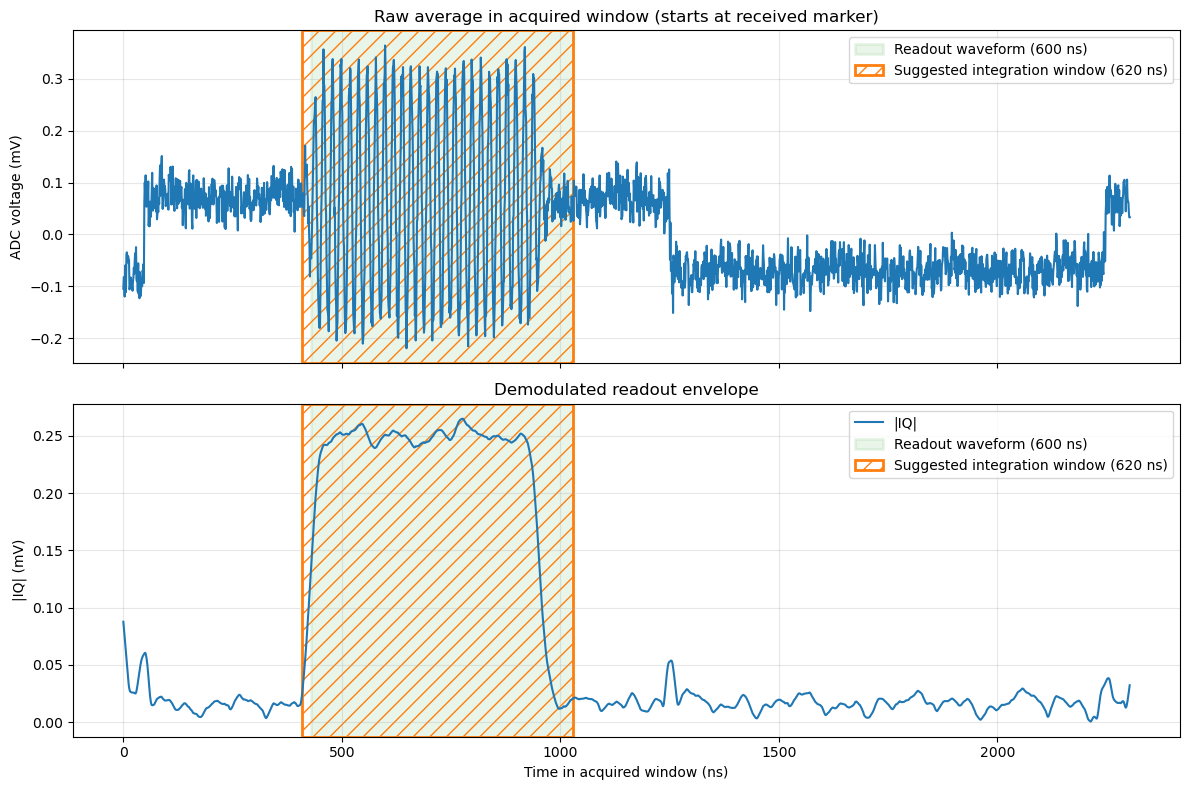

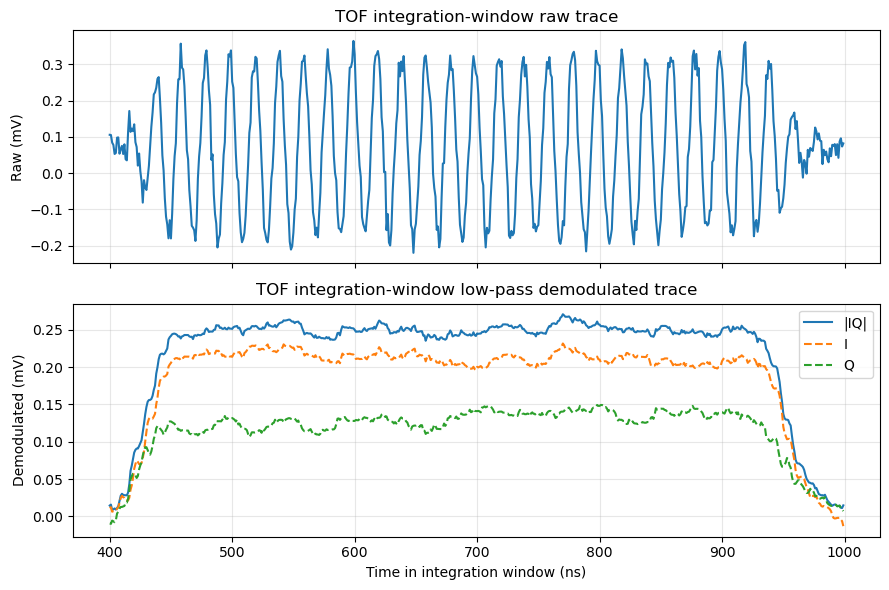

Suggested integration delay: 409.575 ns
Suggested integration time: 620.000 ns
Equivalent trigger delay if moved into ATS delay: 409.575 ns
TOF window samples: (1000, 600)


In [4]:
class TOFProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["integrate_window"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_window"],
        )
        self.add_pulse(
            "tof_pulse",
            gen="readout",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("tof_pulse", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


tof_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "pulse_length": 0.6 * us,
    "integrate_window": 0.6 * us,
    "trigger_delay": 400 * ns,
    "edge_sigma": 20 * ns,
    "readout_gain": 1,
    "marker_padding": 300 * ns,
}

tof_compiled = TOFProgram(tof_cfg, final_delay_s=1 * us).compile(
    hardware=experiment,
)
tof_compiled.upload()
experiment.configure_experiment(
    tone_frequency_hz=tof_compiled.readout.demod_frequency_hz,
    trigger_delay_s=tof_compiled.trigger_delay_s,
    integrate_time_s=tof_compiled.readout.integrate_time_s
    or tof_compiled.readout.length_s,
    adc_channel=tof_compiled.readout.adc_channel,
)

tof_acquire = experiment.acquire_decimate(n_average=TOF_N_AVERAGE)
if len(tof_acquire) != 3:
    raise RuntimeError(
        "This notebook kernel is still using the old AWGAlazar.acquire_decimate(). "
        "Re-run the import cell and hardware setup cell, or restart the kernel."
    )
tof_window_time_s, tof_raw_window, tof_downconverted_window = tof_acquire
tof_full_raw = experiment.last_records_volts
tof_full_iq = experiment.last_downconverted_iq
tof_full_time_s = experiment.last_time_s
if tof_full_raw is None or tof_full_iq is None or tof_full_time_s is None:
    raise RuntimeError("TOF acquisition did not retain full-window data")

tof_result = ExperimentResult(
    axes={},
    point_coordinates=({},),
    raw=tof_full_raw[:, None, :],
    iq_traces=tof_full_iq[:, None, :],
    iq_shots=np.mean(tof_downconverted_window, axis=1)[:, None],
    raw_time_s=tof_full_time_s,
    iq_time_s=tof_full_time_s,
    readout_name="ro",
    initial_trigger_delay_s=tof_cfg["trigger_delay"],
    readout_windows_s=np.array([[0.0, tof_cfg["pulse_length"]]]),
    acquire_window_s=experiment.acquire_window_ns * 1e-9,
)

window = calculate_window(tof_result)


tof_time_ns = tof_window_time_s / ns
tof_raw_mean_mv = np.mean(tof_raw_window, axis=0) * 1e3
tof_iq_mean_mv = np.mean(tof_downconverted_window, axis=0) * 1e3
tof_iq_abs_mv = np.abs(tof_iq_mean_mv)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(tof_time_ns, tof_raw_mean_mv)
axes[0].set_ylabel("Raw (mV)")
axes[0].set_title("TOF integration-window raw trace")
axes[0].grid(True, alpha=0.3)

axes[1].plot(tof_time_ns, tof_iq_abs_mv, label="|IQ|")
axes[1].plot(tof_time_ns, tof_iq_mean_mv.real, "--", label="I")
axes[1].plot(tof_time_ns, tof_iq_mean_mv.imag, "--", label="Q")
axes[1].set_xlabel("Time in integration window (ns)")
axes[1].set_ylabel("Demodulated (mV)")
axes[1].set_title("TOF integration-window low-pass demodulated trace")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

SUGGESTED_TRIGGER_DELAY = window.suggested_trigger_delay_s
SUGGESTED_INTEGRATION_DELAY = window.integration_start_s
SUGGESTED_INTEGRATION_TIME = window.integration_stop_s - window.integration_start_s

print(f"Suggested integration delay: {SUGGESTED_INTEGRATION_DELAY / ns:.3f} ns")
print(f"Suggested integration time: {SUGGESTED_INTEGRATION_TIME / ns:.3f} ns")
print(
    "Equivalent trigger delay if moved into ATS delay: "
    f"{SUGGESTED_TRIGGER_DELAY / ns:.3f} ns"
)
print("TOF window samples:", tof_raw_window.shape)

## 2. Resonator spectroscopy

In [5]:
class ResonatorReadoutProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["pulse_length"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_window"],
        )
        self.add_pulse(
            "readout_pulse",
            gen="readout",
            style="const",
            length=cfg["pulse_length"],
            frequency=cfg["if_frequency_hz"],
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("readout_pulse", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


readout_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "pulse_length": 1.0 * us,
    "integrate_window": 1.0 * us,
    "trigger_delay": SUGGESTED_TRIGGER_DELAY,
    "readout_gain": 1,
    "marker_padding": Marker_PADDING,
}

readout_compiled = ResonatorReadoutProgram(
    readout_cfg,
    final_delay_s=1 * us,
).compile(hardware=experiment)
readout_compiled.upload()

'ResonatorReadoutProgram'

001/21: 5.840000000 GHz, |IQ|=0.4520 mV
002/21: 5.841000000 GHz, |IQ|=0.5028 mV
003/21: 5.842000000 GHz, |IQ|=0.5657 mV
004/21: 5.843000000 GHz, |IQ|=0.6439 mV
005/21: 5.844000000 GHz, |IQ|=0.7478 mV
006/21: 5.845000000 GHz, |IQ|=0.8810 mV
007/21: 5.846000000 GHz, |IQ|=1.0423 mV
008/21: 5.847000000 GHz, |IQ|=1.1827 mV
009/21: 5.848000000 GHz, |IQ|=1.2206 mV
010/21: 5.849000000 GHz, |IQ|=1.1169 mV
011/21: 5.850000000 GHz, |IQ|=0.9551 mV
012/21: 5.851000000 GHz, |IQ|=0.8096 mV
013/21: 5.852000000 GHz, |IQ|=0.6934 mV
014/21: 5.853000000 GHz, |IQ|=0.6047 mV
015/21: 5.854000000 GHz, |IQ|=0.5363 mV
016/21: 5.855000000 GHz, |IQ|=0.4834 mV
017/21: 5.856000000 GHz, |IQ|=0.4392 mV
018/21: 5.857000000 GHz, |IQ|=0.4028 mV
019/21: 5.858000000 GHz, |IQ|=0.3687 mV
020/21: 5.859000000 GHz, |IQ|=0.3417 mV
021/21: 5.860000000 GHz, |IQ|=0.3165 mV


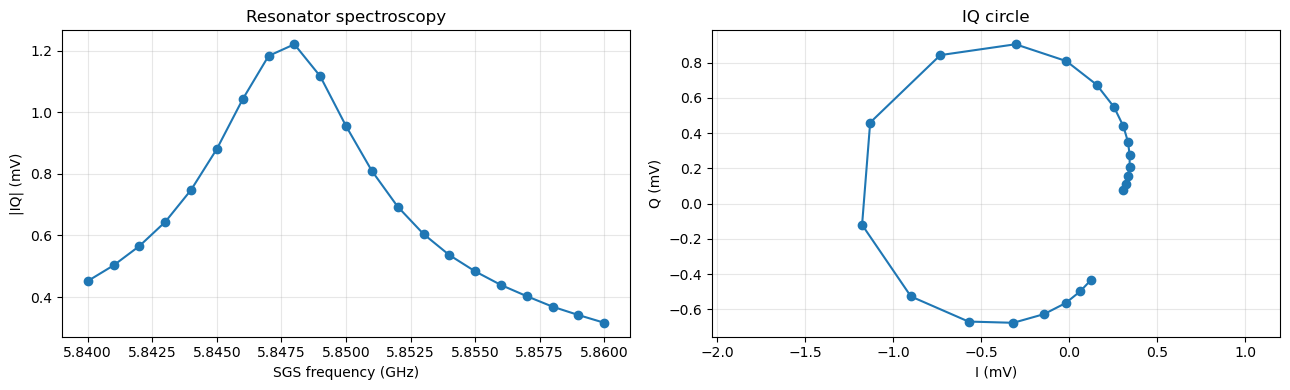

Selected SGS frequency: 5.848000000 GHz


In [6]:
resonator_design = 5.9e9
freqlist = resonator_design -IF_FREQUENCY_HZ + np.linspace(-10e6, 10e6, 21)
resonator_iq = np.empty(freqlist.size, dtype=np.complex128)

for index, f in enumerate(freqlist):
    sgs.frequency = float(f)
    result = readout_compiled.acquire(
        n_average=SPECTROSCOPY_N_AVERAGE,
        )
    resonator_iq[index] = result.iq_average()[0]
    print(
        f"{index + 1:03d}/{freqlist.size}: "
        f"{f / 1e9:.9f} GHz, "
        f"|IQ|={abs(resonator_iq[index]) * 1e3:.4f} mV"
    )

freq_ghz = freqlist / 1e9
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(freq_ghz, np.abs(resonator_iq) * 1e3, "o-")
axes[0].set_xlabel("SGS frequency (GHz)")
axes[0].set_ylabel("|IQ| (mV)")
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Resonator spectroscopy")

axes[1].plot(resonator_iq.real * 1e3, resonator_iq.imag * 1e3, "o-")
axes[1].set_xlabel("I (mV)")
axes[1].set_ylabel("Q (mV)")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.3)
axes[1].set_title("IQ circle")
plt.tight_layout()
plt.show()

best_index = int(np.argmax(np.abs(resonator_iq)))
RESONATOR_SGS_FREQUENCY = float(freqlist[best_index])
sgs.frequency = RESONATOR_SGS_FREQUENCY
print(f"Selected SGS frequency: {RESONATOR_SGS_FREQUENCY / 1e9:.9f} GHz")

## 3. Single shot

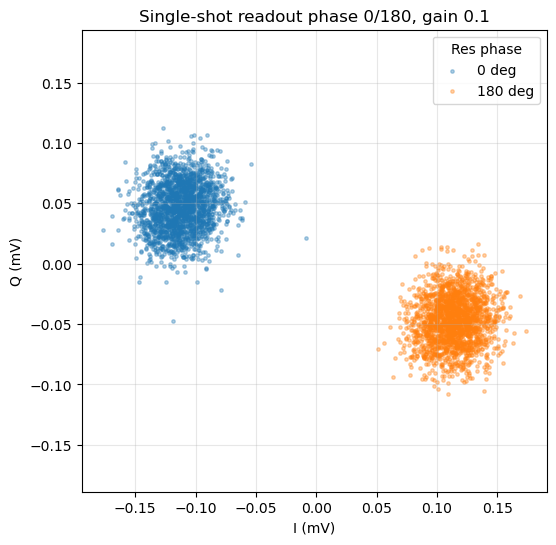

In [7]:
class DemoSingleShotProgram(ExperimentProgram):
    def _initialize(self, cfg):
        phase = self.add_sweep("res_phase", ValuesSweep((0.0, np.pi)))
        self.res_phase = phase
        self.declare_gen(
            "readout",
            ch=cfg["res_ch"],
            amplitude_vpp=cfg["res_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["ro_len"],
            demod_freq=cfg["f_res"],
            waveform_ch=cfg["res_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "readout_pulse",
            gen="readout",
            style="const",
            length=cfg["res_len"],
            frequency=cfg["f_res"],
            phase=phase,
            gain=cfg["res_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("readout_pulse", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


single_shot_cfg = {
    "res_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "marker_padding": Marker_PADDING,
    "adc_channel": ADC_CHANNEL,
    "res_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "f_res": IF_FREQUENCY_HZ,
    "res_len": 1.0 * us,
    "ro_len": 1.0 * us,
    "res_gain": 0.1,
    "integrate_time": 1.0 * us,
    "trigger_delay": SUGGESTED_TRIGGER_DELAY,
}

single_shot_compiled = DemoSingleShotProgram(
    single_shot_cfg,
    final_delay_s=1 * us,
).compile(hardware=experiment)
single_shot_result = single_shot_compiled.acquire(
    n_average=SINGLE_SHOT_N_AVERAGE,
)

res_phases = single_shot_result.axis("res_phase")
res_phase_degrees = np.rad2deg(res_phases)
shots = single_shot_result.shots("ro")

plt.figure(figsize=(6, 6))
for step, phase_degree in enumerate(res_phase_degrees):
    plt.scatter(
        shots[:, step].real * 1e3,
        shots[:, step].imag * 1e3,
        s=6,
        alpha=0.35,
        label=f"{phase_degree:.0f} deg",
    )
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.title(f"Single-shot readout phase 0/180, gain {single_shot_cfg['res_gain']}")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(title="Res phase")
plt.show()

## 4. Temporal-mode heterodyne tomography

This section separates the experiment into two acquisitions:

1. **Strong coherent calibration (`gain=1`)**
   - Verify that the complete signal path works.
   - Verify marker and Alazar timing.
   - Measure the complex temporal envelope.
   - Construct one normalized matched temporal mode.
2. **Weak-state tomography**
   - Acquire a new reference/signal data set.
   - Project every single-shot IQ trace onto the calibrated temporal mode.
   - Normalize the reference distribution.
   - Reconstruct a physical density matrix with maximum likelihood.

The strong calibration pulse is **not** the quantum state being reconstructed.
For a real Fock-state experiment, replace the weak coherent `signal_pulse` with
the qubit/cavity photon-preparation and release sequence. The temporal-mode
projection and analysis cells can remain the same.

Important limitations:

- The current reference-variance normalization treats the complete measured
  reference noise as ideal heterodyne vacuum noise.
- Photon number and Wigner negativity are not quantitatively physical until
  amplifier added noise and total measurement efficiency are calibrated.
- An ideal Fock state has zero mean field. Its temporal mode must therefore be
  obtained from an independent coherent calibration, a phase-coherent
  \(|0\rangle+|1\rangle\) calibration, or a covariance/PCA analysis.

### 4.1 Frequency and timing convention

The cavity is near \(5.9\ \mathrm{GHz}\). This notebook generates a
\(50\ \mathrm{MHz}\) IQ waveform and uses the upper sideband:

\[
f_\mathrm{cavity}=f_\mathrm{LO}+f_\mathrm{IF}.
\]

The resonator-spectroscopy section stores the selected **SGS LO frequency** in
`RESONATOR_SGS_FREQUENCY`.

Marker padding and Alazar trigger delay are different quantities:

\[
t_\mathrm{acquisition}-t_\mathrm{pulse}
=t_\mathrm{trigger}-t_\mathrm{padding}.
\]

For 500 ns padding and 580 ns trigger delay, Alazar acquisition starts 80 ns
after the pulse begins. A 600 ns calibration pulse therefore remains on for
approximately the first 520 ns of the acquired trace.

In [24]:
from datetime import datetime

from QAWG.tomography import coherent_density_matrix

# The resonator scan stores an SGS/LO frequency, not the physical cavity
# frequency. If section 2 was not run, use the value found during hardware
# debugging: cavity ~= 5.898 GHz and LO ~= 5.848 GHz.
if "RESONATOR_SGS_FREQUENCY" in globals():
    TOMO_LO_FREQUENCY_HZ = float(RESONATOR_SGS_FREQUENCY)
    TOMO_CAVITY_FREQUENCY_HZ = TOMO_LO_FREQUENCY_HZ + IF_FREQUENCY_HZ
else:
    TOMO_CAVITY_FREQUENCY_HZ = 5.898e9
    TOMO_LO_FREQUENCY_HZ = TOMO_CAVITY_FREQUENCY_HZ - IF_FREQUENCY_HZ

TOMO_MARKER_PADDING = 500 * ns
TOMO_TRIGGER_DELAY = 580 * ns
TOMO_PULSE_LENGTH = 600 * ns
# Use the complete 1.5 us Alazar record. The measured response arrives
# late in the record, so an 800 ns mode window truncates the envelope.
TOMO_READOUT_LENGTH = 1500 * ns

# Start conservatively. The hardware debug test found a clear signal with
# SGS=-10 dBm and AWG gain=1, while remaining far from Alazar clipping.
TOMO_SGS_POWER_DBM = -10.0
TOMO_CALIBRATION_GAIN = 1.0
TOMO_CALIBRATION_SHOTS = 300

# This is a weak coherent demonstration state. Replace its preparation with
# the actual qubit/cavity photon-release sequence for Fock-state tomography.
TOMO_STATE_GAIN = 0.5
TOMO_STATE_SHOTS = 5000

# Optional manual override for the cavity power linewidth kappa / (2*pi).
# Leave as None to fit the complex resonator spectroscopy data from section 2.
TOMO_KAPPA_OVER_2PI_HZ = None

# iq_time_s is marker-relative in the current QAWG acquisition model.
# The compiler shifts the pulse by marker_padding so the marker can lead it.
TOMO_PULSE_START_IN_TRACE = TOMO_MARKER_PADDING
TOMO_PULSE_END_IN_TRACE = TOMO_MARKER_PADDING + TOMO_PULSE_LENGTH
TOMO_MODE_START = TOMO_TRIGGER_DELAY
TOMO_MODE_STOP = TOMO_TRIGGER_DELAY + TOMO_READOUT_LENGTH

print(f"Cavity target: {TOMO_CAVITY_FREQUENCY_HZ / 1e9:.9f} GHz")
print(f"SGS LO: {TOMO_LO_FREQUENCY_HZ / 1e9:.9f} GHz")
print(f"IF: {IF_FREQUENCY_HZ / 1e6:.3f} MHz")
print(f"Alazar channel: {ADC_CHANNEL}")
print(f"Marker padding: {TOMO_MARKER_PADDING / ns:.1f} ns")
print(f"Trigger delay: {TOMO_TRIGGER_DELAY / ns:.1f} ns")
print("Saved trace starts at the marker edge: iq_time_s = 0")
print(
    "Tomography mode window: "
    f"{TOMO_MODE_START / ns:.1f} to {TOMO_MODE_STOP / ns:.1f} ns"
)
print(
    "Programmed pulse window in the marker-relative trace: "
    f"{TOMO_PULSE_START_IN_TRACE / ns:.1f} to "
    f"{TOMO_PULSE_END_IN_TRACE / ns:.1f} ns"
)

Cavity target: 5.898000000 GHz
SGS LO: 5.848000000 GHz
IF: 50.000 MHz
Alazar channel: CHB
Marker padding: 500.0 ns
Trigger delay: 580.0 ns
Saved trace starts at the marker edge: iq_time_s = 0
Tomography mode window: 580.0 to 2080.0 ns
Programmed pulse window in the marker-relative trace: 500.0 to 1100.0 ns


### 4.2 Reference/signal acquisition program

Each sequence cycle contains two interleaved states:

- `reference`: identical marker and acquisition timing, but AWG pulse gain is
  zero.
- `signal`: the coherent calibration or weak demonstration pulse.

Interleaving the two states reduces sensitivity to slow gain and offset drift.
`readout=True` tells the QAWG compiler which pulse owns the readout marker.

The only custom class below describes the hardware sequence. Temporal-mode
projection, normalization, and maximum-likelihood reconstruction use the
functions already provided by `QAWG.tomography`.

In [25]:
class TemporalModeTomographyProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.state = self.add_sweep(
            "state",
            ValuesSweep(("reference", "signal")),
        )
        self.declare_gen(
            "cavity",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["readout_length"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["readout_length"],
        )
        self.add_pulse(
            "reference_pulse",
            gen="cavity",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            gain=0.0,
            readout=True,
        )
        self.add_pulse(
            "signal_pulse",
            gen="cavity",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            gain=cfg["signal_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play(
            "reference_pulse",
            at=0,
            when=("state", "reference"),
        )
        self.play(
            "signal_pulse",
            at=0,
            when=("state", "signal"),
        )
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


tomography_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": "CHB",
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "pulse_length": TOMO_PULSE_LENGTH,
    "edge_sigma": 20 * ns,
    "readout_length": TOMO_READOUT_LENGTH,
    "marker_padding": TOMO_MARKER_PADDING,
    "trigger_delay": TOMO_TRIGGER_DELAY,
    "signal_gain": TOMO_CALIBRATION_GAIN,
}

### 4.3 Compile and inspect before enabling RF

Compiling first catches channel, timing, and sequence-layout mistakes without
running an acquisition. There should be two sequence points: `reference` and
`signal`.

The acquisition channel is intentionally fixed to **CHB**.

In [26]:
calibration_program = TemporalModeTomographyProgram(
    tomography_cfg,
    name="TemporalModeCalibration",
    final_delay_s=2 * us,
)
calibration_compiled = calibration_program.compile(hardware=experiment)

print("Sequence points:", calibration_compiled.number_of_sequence_steps)
print("State axis:", calibration_compiled.axis("state"))
print("Alazar channel:", calibration_compiled.readout.adc_channel)
print(
    "Compiled trigger delay:",
    calibration_compiled.trigger_delay_s / ns,
    "ns",
)
print("Marker waveform shape:", calibration_compiled.marker_waveforms.shape)

assert calibration_compiled.number_of_sequence_steps == 2
assert calibration_compiled.readout.adc_channel == "CHB"
assert np.isclose(
    calibration_compiled.trigger_delay_s,
    TOMO_TRIGGER_DELAY,
)

Sequence points: 2
State axis: ['reference' 'signal']
Alazar channel: CHB
Compiled trigger delay: 580.0 ns
Marker waveform shape: (2, 10000)


### 4.4 Strong coherent calibration acquisition

This acquisition uses `gain=1` only to make the signal path easy to diagnose.
The SGS RF output is turned off in `finally`, even if acquisition raises an
exception.

The result retains every individual shot:

- `result.raw`: raw Alazar voltage traces.
- `result.iq_traces`: digitally downconverted complex IQ traces.
- first sequence index: reference.
- second sequence index: signal.

The full shot-resolved arrays are saved before further processing so temporal
filters can be changed without repeating the experiment.

In [27]:
sgs.off()
sgs.frequency = TOMO_LO_FREQUENCY_HZ
sgs.power = TOMO_SGS_POWER_DBM
sgs.IQ_state = "on"
sgs.pulsemod_state = "off"
sgs.configure_lo_output(True, mode="LO")

try:
    sgs.on()
    calibration_result = calibration_compiled.acquire(
        n_average=TOMO_CALIBRATION_SHOTS,
    )
finally:
    sgs.off()

calibration_states = list(calibration_result.axis("state"))
reference_index = calibration_states.index("reference")
signal_index = calibration_states.index("signal")

calibration_reference_iq = calibration_result.iq_traces[
    :, reference_index, :
]
calibration_signal_iq = calibration_result.iq_traces[
    :, signal_index, :
]
calibration_reference_raw = calibration_result.raw[
    :, reference_index, :
]
calibration_signal_raw = calibration_result.raw[
    :, signal_index, :
]

# The compiled reference waveform is exactly zero and the signal waveform is
# nonzero. If the measured reference contains the strong coherent pulse while
# signal does not, the AWG sequence did not restart from step one.
calibration_check_start = int(
    round(TOMO_MODE_START * ALAZAR_SAMPLE_RATE_HZ)
)
calibration_check_stop = int(
    round(TOMO_MODE_STOP * ALAZAR_SAMPLE_RATE_HZ)
)
calibration_check_stop = min(
    calibration_check_stop,
    calibration_reference_iq.shape[1],
)
reference_check_level = np.linalg.norm(
    np.mean(
        calibration_reference_iq[
            :, calibration_check_start:calibration_check_stop
        ],
        axis=0,
    )
)
signal_check_level = np.linalg.norm(
    np.mean(
        calibration_signal_iq[
            :, calibration_check_start:calibration_check_stop
        ],
        axis=0,
    )
)
print(f"Reference mean-trace norm: {reference_check_level:.6g}")
print(f"Signal mean-trace norm: {signal_check_level:.6g}")
if reference_check_level >= signal_check_level:
    raise RuntimeError(
        "Reference/signal acquisition order is inconsistent: the zero-gain "
        "reference is stronger than the gain=1 signal. Restart the kernel so "
        "the updated QAWG driver can rewind the AWG sequence before capture."
    )

output_dir = PROJECT_ROOT / "diagnostics" / "tomography"
output_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
calibration_path = output_dir / f"temporal_mode_calibration_{timestamp}.npz"

np.savez_compressed(
    calibration_path,
    raw_time_s=calibration_result.raw_time_s,
    iq_time_s=calibration_result.iq_time_s,
    reference_raw=calibration_reference_raw,
    signal_raw=calibration_signal_raw,
    reference_iq=calibration_reference_iq,
    signal_iq=calibration_signal_iq,
    cavity_frequency_hz=TOMO_CAVITY_FREQUENCY_HZ,
    lo_frequency_hz=TOMO_LO_FREQUENCY_HZ,
    if_frequency_hz=IF_FREQUENCY_HZ,
    marker_padding_s=TOMO_MARKER_PADDING,
    trigger_delay_s=TOMO_TRIGGER_DELAY,
    pulse_length_s=TOMO_PULSE_LENGTH,
    signal_gain=TOMO_CALIBRATION_GAIN,
)

print("Calibration raw shape:", calibration_result.raw.shape)
print("Calibration IQ shape:", calibration_result.iq_traces.shape)
print("Saved calibration:", calibration_path)

Reference mean-trace norm: 0.000545717
Signal mean-trace norm: 0.00741373
Calibration raw shape: (300, 2, 2304)
Calibration IQ shape: (300, 2, 2304)
Saved calibration: C:\Users\cluster\Desktop\Qawg-main\diagnostics\tomography\temporal_mode_calibration_20260618_132613.npz


### 4.5 Check clipping, timing, and the measured envelope

The ATS9371 input range in the current driver is $(\pm 400\ \mathrm{mV})$.
The raw trace should remain comfortably inside this range.

The green curve is the coherent response used to determine the temporal mode:

$$
u(t)=\langle S_\mathrm{signal}(t)\rangle
-\langle S_\mathrm{reference}(t)\rangle.
$$

With the present timing, the driven plateau should end near 520 ns in the
Alazar trace. Features common to both reference and signal are usually marker
feedthrough or acquisition/filter transients and should cancel in the green
difference trace.

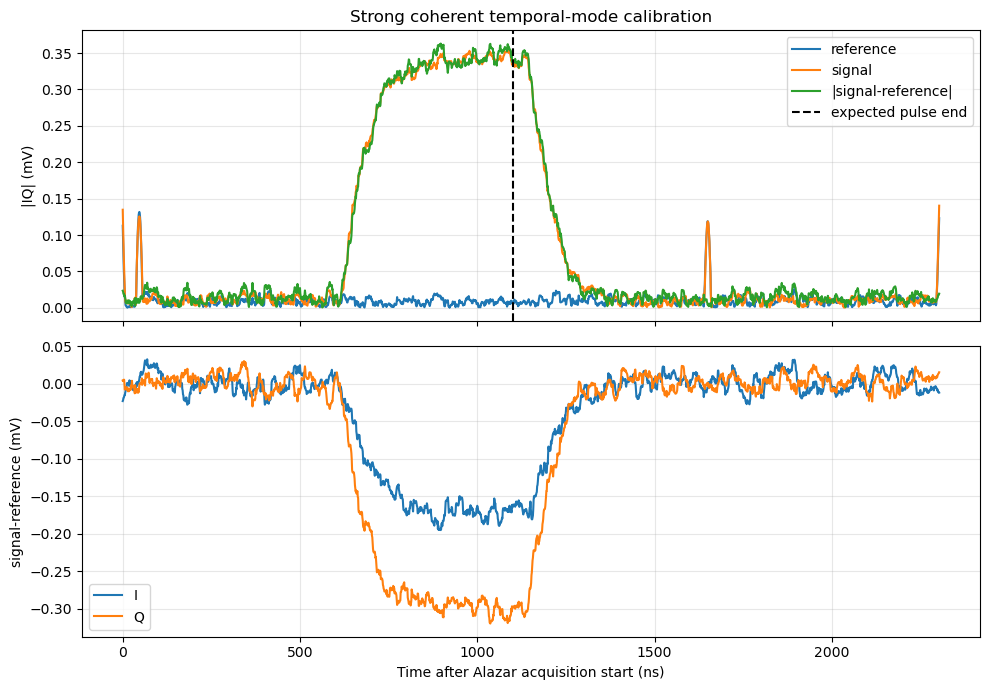

Raw peak: 2.1562 mV
Fraction of +/-400 mV input range: 0.005391
ADC has substantial headroom; clipping is not limiting this run.


In [28]:
calibration_time_ns = calibration_result.iq_time_s / ns
mean_reference_iq = np.mean(calibration_reference_iq, axis=0)
mean_signal_iq = np.mean(calibration_signal_iq, axis=0)
mean_difference_iq = mean_signal_iq - mean_reference_iq

raw_peak_volts = max(
    np.max(np.abs(calibration_reference_raw)),
    np.max(np.abs(calibration_signal_raw)),
)
raw_range_fraction = raw_peak_volts / 0.4

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(
    calibration_time_ns,
    np.abs(mean_reference_iq) * 1e3,
    label="reference",
)
axes[0].plot(
    calibration_time_ns,
    np.abs(mean_signal_iq) * 1e3,
    label="signal",
)
axes[0].plot(
    calibration_time_ns,
    np.abs(mean_difference_iq) * 1e3,
    label="|signal-reference|",
)
axes[0].axvline(
    TOMO_PULSE_END_IN_TRACE / ns,
    color="black",
    linestyle="--",
    label="expected pulse end",
)
axes[0].set_ylabel("|IQ| (mV)")
axes[0].set_title("Strong coherent temporal-mode calibration")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(calibration_time_ns, mean_difference_iq.real * 1e3, label="I")
axes[1].plot(calibration_time_ns, mean_difference_iq.imag * 1e3, label="Q")
axes[1].set_xlabel("Time after Alazar acquisition start (ns)")
axes[1].set_ylabel("signal-reference (mV)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Raw peak: {raw_peak_volts * 1e3:.4f} mV")
print(f"Fraction of +/-400 mV input range: {raw_range_fraction:.6f}")
if raw_range_fraction > 0.8:
    print("WARNING: Alazar input is close to clipping.")
elif raw_range_fraction < 0.01:
    print("ADC has substantial headroom; clipping is not limiting this run.")

### 4.6 Build the complex temporal matched filter

The complete selected 1.5 us readout region is used to construct the mode.
The saved raw data also contains the complete acquisition record.

The normalized calibration mode is

\[
f_j=\frac{u_j}{\sqrt{\sum_k|u_k|^2}}.
\]

`project_temporal_mode` then evaluates, for every shot,

\[
S_k=\sum_j z_{k,j}f_j^*.
\]

The phase of `f` is retained. This is important when the cavity is slightly
detuned or the measured envelope rotates in the IQ plane.

For comparison, the cell also constructs a QAWG boxcar mode. The matched mode
should normally give the larger displacement-to-noise ratio.

Available calibration IQ samples: 2304
Temporal-mode start sample: 580
Temporal-mode stop sample: 2080
Temporal-mode samples used: 1500
Temporal-mode time window: 580.0 to 2079.0 ns


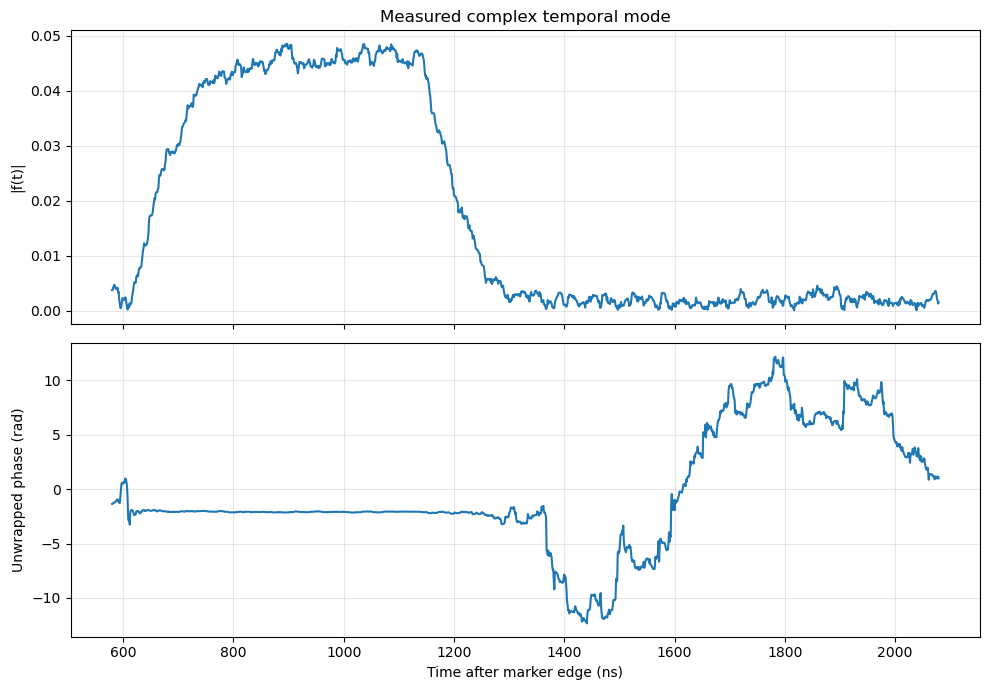

Matched-mode displacement/reference-RMS SNR: 9.4220
Boxcar displacement/reference-RMS SNR: 5.9405
Mode normalization: 0.9999999999999997
Final 5% envelope / peak: 0.0353


In [29]:
mode_start_sample = int(
    round(TOMO_MODE_START * ALAZAR_SAMPLE_RATE_HZ)
)
mode_stop_sample = int(
    round(TOMO_MODE_STOP * ALAZAR_SAMPLE_RATE_HZ)
)
mode_stop_sample = min(
    mode_stop_sample,
    calibration_reference_iq.shape[1],
)
mode_samples = mode_stop_sample - mode_start_sample
if mode_samples < 1:
    raise RuntimeError("The temporal-mode window is outside the acquired trace")

mode_time_ns = (
    calibration_result.iq_time_s[
        mode_start_sample:mode_stop_sample
    ]
    / ns
)

print("Available calibration IQ samples:", calibration_reference_iq.shape[1])
print("Temporal-mode start sample:", mode_start_sample)
print("Temporal-mode stop sample:", mode_stop_sample)
print("Temporal-mode samples used:", mode_samples)
print(
    "Temporal-mode time window:",
    f"{mode_time_ns[0]:.1f} to {mode_time_ns[-1]:.1f} ns",
)

calibration_envelope = (
    np.mean(
        calibration_signal_iq[
            :, mode_start_sample:mode_stop_sample
        ],
        axis=0,
    )
    - np.mean(
        calibration_reference_iq[
            :, mode_start_sample:mode_stop_sample
        ],
        axis=0,
    )
)
calibration_envelope_norm = np.linalg.norm(calibration_envelope)
if calibration_envelope_norm <= np.finfo(float).eps:
    raise RuntimeError(
        "The coherent calibration envelope is indistinguishable from noise"
    )

matched_mode = np.asarray(
    calibration_envelope / calibration_envelope_norm,
    dtype=np.complex128,
)
boxcar_mode = temporal_mode_weights(mode_samples, kind="boxcar")

matched_reference = project_temporal_mode(
    calibration_reference_iq,
    matched_mode,
    start_sample=mode_start_sample,
)
matched_signal = project_temporal_mode(
    calibration_signal_iq,
    matched_mode,
    start_sample=mode_start_sample,
)
boxcar_reference = project_temporal_mode(
    calibration_reference_iq,
    boxcar_mode,
    start_sample=mode_start_sample,
)
boxcar_signal = project_temporal_mode(
    calibration_signal_iq,
    boxcar_mode,
    start_sample=mode_start_sample,
)

matched_noise_rms = np.sqrt(
    np.mean(np.abs(matched_reference - np.mean(matched_reference)) ** 2)
)
matched_displacement = abs(np.mean(matched_signal) - np.mean(matched_reference))
matched_snr = matched_displacement / matched_noise_rms

boxcar_noise_rms = np.sqrt(
    np.mean(np.abs(boxcar_reference - np.mean(boxcar_reference)) ** 2)
)
boxcar_displacement = abs(np.mean(boxcar_signal) - np.mean(boxcar_reference))
boxcar_snr = boxcar_displacement / boxcar_noise_rms

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(mode_time_ns, np.abs(matched_mode))
axes[0].set_ylabel("|f(t)|")
axes[0].set_title("Measured complex temporal mode")
axes[0].grid(True, alpha=0.3)

axes[1].plot(mode_time_ns, np.unwrap(np.angle(matched_mode)))
axes[1].set_xlabel("Time after marker edge (ns)")
axes[1].set_ylabel("Unwrapped phase (rad)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Matched-mode displacement/reference-RMS SNR: {matched_snr:.4f}")
print(f"Boxcar displacement/reference-RMS SNR: {boxcar_snr:.4f}")
print("Mode normalization:", np.sum(np.abs(matched_mode) ** 2))

# A valid mode should return close to its off-pulse baseline before the
# selected window ends. Compare the final 5% with the peak amplitude.
tail_samples = max(10, mode_samples // 20)
mode_tail_fraction = (
    np.mean(np.abs(calibration_envelope[-tail_samples:]))
    / np.max(np.abs(calibration_envelope))
)
print(f"Final 5% envelope / peak: {mode_tail_fraction:.4f}")
if mode_tail_fraction > 0.1:
    print(
        "WARNING: The temporal envelope has not returned to baseline at the "
        "end of the selected window. Increase ACQUIRE_WINDOW and "
        "TOMO_READOUT_LENGTH, then reacquire the calibration data."
    )


### 4.7 Compare the measured mode with a spectroscopy-derived $\kappa$ mode

The complex spectroscopy data are fitted to a single-pole resonator response.
The fitted power linewidth is $\kappa/(2\pi)$. Because the cavity is still
being driven during the first part of the mode window, the theoretical mode
below includes both cavity buildup during the programmed pulse and exponential
ring-down after the pulse ends. It is therefore not a simple exponential that
starts at the left edge of the window.

`TOMO_KAPPA_OVER_2PI_HZ` can be set in section 4.1 to override the fit. The
measured matched mode remains the default for tomography; this cell provides
an independent comparison without optimizing on the weak-state data.

In [ ]:
from scipy.optimize import least_squares


def _single_pole_iq(frequency_hz, parameters):
    f0_hz, log_linewidth_hz, c0_real, c0_imag, c1_real, c1_imag = parameters
    linewidth_hz = np.exp(log_linewidth_hz)
    background = c0_real + 1j * c0_imag
    response = c1_real + 1j * c1_imag
    return background + response / (
        1.0 + 2j * (frequency_hz - f0_hz) / linewidth_hz
    )


def _fit_resonator_linewidth(frequency_hz, complex_iq):
    frequency_hz = np.asarray(frequency_hz, dtype=float)
    complex_iq = np.asarray(complex_iq, dtype=np.complex128)
    order = np.argsort(frequency_hz)
    frequency_hz = frequency_hz[order]
    complex_iq = complex_iq[order]
    spacing_hz = np.median(np.diff(frequency_hz))
    span_hz = np.ptp(frequency_hz)
    edge_count = max(1, min(3, frequency_hz.size // 4))
    background0 = np.mean(
        np.r_[complex_iq[:edge_count], complex_iq[-edge_count:]]
    )
    resonance_index = int(np.argmax(np.abs(complex_iq - background0)))
    f0_initial_hz = frequency_hz[resonance_index]
    linewidth_initial_hz = max(2.0 * spacing_hz, span_hz / 10.0)
    response0 = complex_iq[resonance_index] - background0
    initial = np.array([
        f0_initial_hz,
        np.log(linewidth_initial_hz),
        background0.real,
        background0.imag,
        response0.real,
        response0.imag,
    ])
    lower = np.array([
        frequency_hz[0],
        np.log(max(spacing_hz / 4.0, 1.0)),
        -np.inf, -np.inf, -np.inf, -np.inf,
    ])
    upper = np.array([
        frequency_hz[-1],
        np.log(max(2.0 * span_hz, spacing_hz)),
        np.inf, np.inf, np.inf, np.inf,
    ])

    def residual(parameters):
        error = _single_pole_iq(frequency_hz, parameters) - complex_iq
        return np.r_[error.real, error.imag]

    fit = least_squares(
        residual,
        initial,
        bounds=(lower, upper),
        x_scale="jac",
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
    )
    fitted_iq = _single_pole_iq(frequency_hz, fit.x)
    residual_power = np.sum(np.abs(complex_iq - fitted_iq) ** 2)
    total_power = np.sum(np.abs(complex_iq - np.mean(complex_iq)) ** 2)
    fit_r_squared = 1.0 - residual_power / total_power
    return {
        "f0_hz": float(fit.x[0]),
        "linewidth_hz": float(np.exp(fit.x[1])),
        "fitted_iq": fitted_iq,
        "r_squared": float(fit_r_squared),
        "success": bool(fit.success),
    }


spectroscopy_fit = None
if "freqlist" in globals() and "resonator_iq" in globals():
    spectroscopy_fit = _fit_resonator_linewidth(freqlist, resonator_iq)
    fitted_kappa_over_2pi_hz = spectroscopy_fit["linewidth_hz"]
    print(
        "Spectroscopy fit resonance (SGS): "
        f"{spectroscopy_fit['f0_hz'] / 1e9:.9f} GHz"
    )
    print(
        "Fitted kappa/(2*pi): "
        f"{fitted_kappa_over_2pi_hz / 1e6:.4f} MHz"
    )
    print(f"Complex-fit R^2: {spectroscopy_fit['r_squared']:.5f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(freq_ghz, np.abs(resonator_iq) * 1e3, "o", label="data")
    axes[0].plot(
        freq_ghz,
        np.abs(spectroscopy_fit["fitted_iq"]) * 1e3,
        "-",
        label="single-pole fit",
    )
    axes[0].set_xlabel("SGS frequency (GHz)")
    axes[0].set_ylabel("|IQ| (mV)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].plot(
        resonator_iq.real * 1e3,
        resonator_iq.imag * 1e3,
        "o",
        label="data",
    )
    axes[1].plot(
        spectroscopy_fit["fitted_iq"].real * 1e3,
        spectroscopy_fit["fitted_iq"].imag * 1e3,
        "-",
        label="single-pole fit",
    )
    axes[1].set_xlabel("I (mV)")
    axes[1].set_ylabel("Q (mV)")
    axes[1].axis("equal")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()
elif TOMO_KAPPA_OVER_2PI_HZ is None:
    raise RuntimeError(
        "Run section 2 spectroscopy or set TOMO_KAPPA_OVER_2PI_HZ manually"
    )

if TOMO_KAPPA_OVER_2PI_HZ is None:
    kappa_over_2pi_hz = fitted_kappa_over_2pi_hz
    kappa_source = "spectroscopy fit"
else:
    kappa_over_2pi_hz = float(TOMO_KAPPA_OVER_2PI_HZ)
    kappa_source = "manual override"
if kappa_over_2pi_hz <= 0:
    raise ValueError("TOMO_KAPPA_OVER_2PI_HZ must be positive")

# Simulate da/dt = -(kappa/2 - i*Delta)*a + drive(t) over the complete trace.
# kappa/(2*pi) is the fitted power linewidth, so kappa/2 = pi*linewidth.
full_time_s = np.asarray(calibration_result.iq_time_s, dtype=float)
sample_interval_s = float(np.median(np.diff(full_time_s)))
if spectroscopy_fit is None:
    resonance_sgs_hz = TOMO_LO_FREQUENCY_HZ
else:
    resonance_sgs_hz = spectroscopy_fit["f0_hz"]
detuning_hz = TOMO_LO_FREQUENCY_HZ - resonance_sgs_hz
complex_pole_per_s = (
    np.pi * kappa_over_2pi_hz - 2j * np.pi * detuning_hz
)
step_decay = np.exp(-complex_pole_per_s * sample_interval_s)
drive = (
    (full_time_s >= TOMO_PULSE_START_IN_TRACE)
    & (full_time_s < TOMO_PULSE_END_IN_TRACE)
).astype(float)
kappa_response = np.zeros(full_time_s.size, dtype=np.complex128)
drive_step = (1.0 - step_decay) / complex_pole_per_s
for sample_index in range(1, full_time_s.size):
    kappa_response[sample_index] = (
        step_decay * kappa_response[sample_index - 1]
        + drive_step * drive[sample_index - 1]
    )

kappa_mode = kappa_response[mode_start_sample:mode_stop_sample]
kappa_mode = np.asarray(
    kappa_mode / np.linalg.norm(kappa_mode),
    dtype=np.complex128,
)
kappa_reference = project_temporal_mode(
    calibration_reference_iq,
    kappa_mode,
    start_sample=mode_start_sample,
)
kappa_signal = project_temporal_mode(
    calibration_signal_iq,
    kappa_mode,
    start_sample=mode_start_sample,
)
kappa_noise_rms = np.sqrt(
    np.mean(np.abs(kappa_reference - np.mean(kappa_reference)) ** 2)
)
kappa_displacement = abs(np.mean(kappa_signal) - np.mean(kappa_reference))
kappa_snr = kappa_displacement / kappa_noise_rms
mode_overlap = abs(np.vdot(matched_mode, kappa_mode)) ** 2

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(mode_time_ns, np.abs(matched_mode), label="measured matched")
axes[0].plot(mode_time_ns, np.abs(kappa_mode), "--", label="kappa model")
axes[0].set_ylabel("|f(t)|")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(
    mode_time_ns,
    np.unwrap(np.angle(matched_mode)),
    label="measured matched",
)
axes[1].plot(
    mode_time_ns,
    np.unwrap(np.angle(kappa_mode)),
    "--",
    label="kappa model",
)
axes[1].set_xlabel("Time after marker edge (ns)")
axes[1].set_ylabel("Unwrapped phase (rad)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Kappa source: {kappa_source}")
print(f"Kappa/(2*pi): {kappa_over_2pi_hz / 1e6:.4f} MHz")
print(f"Drive-resonator detuning: {detuning_hz / 1e6:.4f} MHz")
print(f"Measured matched-mode SNR: {matched_snr:.4f}")
print(f"Kappa-model mode SNR: {kappa_snr:.4f}")
print(f"Kappa/measured SNR ratio: {kappa_snr / matched_snr:.4f}")
print(f"Mode overlap |<measured|kappa>|^2: {mode_overlap:.4f}")
if kappa_snr > matched_snr:
    print("Kappa mode gives the larger calibration SNR on this data set.")
else:
    print("Measured matched mode gives the larger calibration SNR on this data set.")


### 4.8 Acquire the weak demonstration state

The matched mode above is now fixed. Do not re-optimize it using the same weak
data that will be reconstructed, because doing so can bias the result toward
statistical noise.

The default signal is a weak coherent pulse (`gain=0.5`) used to demonstrate
the analysis pipeline. For a single-photon experiment:

1. Keep the same `reference` acquisition.
2. Replace `signal_pulse` with the qubit excitation, state transfer, and cavity
   release sequence.
3. Keep the trigger, CHB acquisition, and calibrated `matched_mode`.
4. Increase the number of shots substantially.

The strong calibration and weak-state data are saved in separate files.

Weak-run reference mean-trace norm: 0.0006505700310913255
Weak-run signal mean-trace norm: 0.0037466227933940256


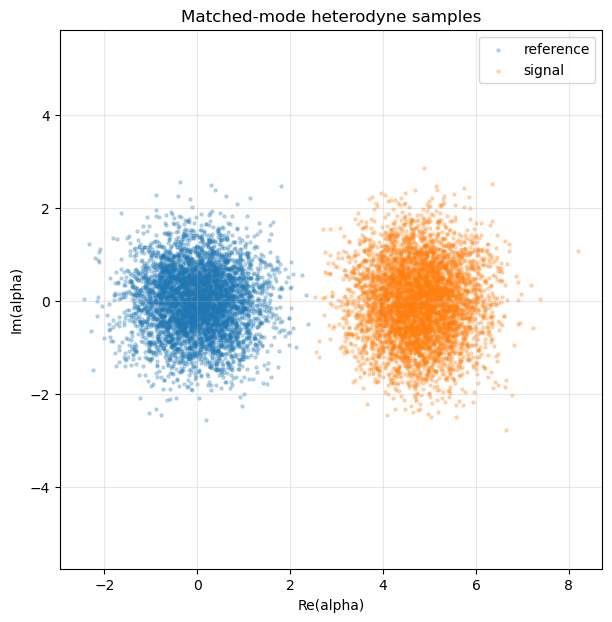

Reference alpha mean: (-1.7763568394002505e-17+9.947598300641403e-18j)
Reference <|alpha|^2>: 1.0
Signal alpha mean: (4.76257331179496-0.02300119978607599j)
Saved tomography data: C:\Users\cluster\Desktop\Qawg-main\diagnostics\tomography\weak_state_tomography_20260618_132613.npz


In [30]:
state_cfg = dict(tomography_cfg)
state_cfg["signal_gain"] = TOMO_STATE_GAIN

state_program = TemporalModeTomographyProgram(
    state_cfg,
    name="WeakStateTomography",
    final_delay_s=2 * us,
)
state_compiled = state_program.compile(hardware=experiment)

sgs.off()
sgs.frequency = TOMO_LO_FREQUENCY_HZ
sgs.power = TOMO_SGS_POWER_DBM
try:
    sgs.on()
    tomography_result = state_compiled.acquire(
        n_average=TOMO_STATE_SHOTS,
    )
finally:
    sgs.off()

tomography_states = list(tomography_result.axis("state"))
reference_index = tomography_states.index("reference")
signal_index = tomography_states.index("signal")

if tomography_result.iq_traces.shape[2] < mode_stop_sample:
    raise RuntimeError(
        "Weak-state traces do not contain the complete calibrated mode window. "
        "Recompile and reacquire with the same acquisition length."
    )

reference_iq = tomography_result.iq_traces[:, reference_index, :]
signal_iq = tomography_result.iq_traces[:, signal_index, :]

# The driver rewinds the AWG sequence before every acquisition. This check is
# intentionally informational for weak or zero-mean quantum states, where the
# signal mean can legitimately be small.
print(
    "Weak-run reference mean-trace norm:",
    np.linalg.norm(np.mean(reference_iq, axis=0)),
)
print(
    "Weak-run signal mean-trace norm:",
    np.linalg.norm(np.mean(signal_iq, axis=0)),
)

reference_samples = project_temporal_mode(
    reference_iq,
    matched_mode,
    start_sample=mode_start_sample,
)
signal_samples = project_temporal_mode(
    signal_iq,
    matched_mode,
    start_sample=mode_start_sample,
)

reference_alpha, (signal_alpha,), iq_offset, iq_scale = (
    normalize_heterodyne_reference(
        reference_samples,
        signal_samples,
    )
)

state_path = output_dir / f"weak_state_tomography_{timestamp}.npz"
np.savez_compressed(
    state_path,
    raw_time_s=tomography_result.raw_time_s,
    iq_time_s=tomography_result.iq_time_s,
    reference_raw=tomography_result.raw[:, reference_index, :],
    signal_raw=tomography_result.raw[:, signal_index, :],
    reference_iq=tomography_result.iq_traces[:, reference_index, :],
    signal_iq=tomography_result.iq_traces[:, signal_index, :],
    matched_mode=matched_mode,
    mode_start_sample=mode_start_sample,
    mode_stop_sample=mode_stop_sample,
    reference_mode_samples=reference_samples,
    signal_mode_samples=signal_samples,
    reference_alpha=reference_alpha,
    signal_alpha=signal_alpha,
    iq_offset=iq_offset,
    iq_scale=iq_scale,
    cavity_frequency_hz=TOMO_CAVITY_FREQUENCY_HZ,
    signal_gain=TOMO_STATE_GAIN,
)

plt.figure(figsize=(7, 7))
plt.scatter(
    reference_alpha.real,
    reference_alpha.imag,
    s=5,
    alpha=0.25,
    label="reference",
)
plt.scatter(
    signal_alpha.real,
    signal_alpha.imag,
    s=5,
    alpha=0.25,
    label="signal",
)
plt.xlabel("Re(alpha)")
plt.ylabel("Im(alpha)")
plt.title("Matched-mode heterodyne samples")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Reference alpha mean:", np.mean(reference_alpha))
print("Reference <|alpha|^2>:", np.mean(np.abs(reference_alpha) ** 2))
print("Signal alpha mean:", np.mean(signal_alpha))
print("Saved tomography data:", state_path)

### 4.9 Maximum-likelihood density matrix and cutoff check

`heterodyne_ml_density_matrix` uses a diluted \(R\rho R\) iteration and
enforces:

\[
\rho=\rho^\dagger,\qquad \rho\geq0,\qquad \mathrm{Tr}(\rho)=1.
\]

The reconstruction is repeated at several Fock cutoffs. A cutoff is not
converged if appreciable population accumulates in its last two bins, or if
the low-number populations change substantially when the cutoff increases.

This likelihood currently assumes an ideal coherent-state heterodyne POVM.
It does not yet include independently calibrated amplifier noise or detection
efficiency.

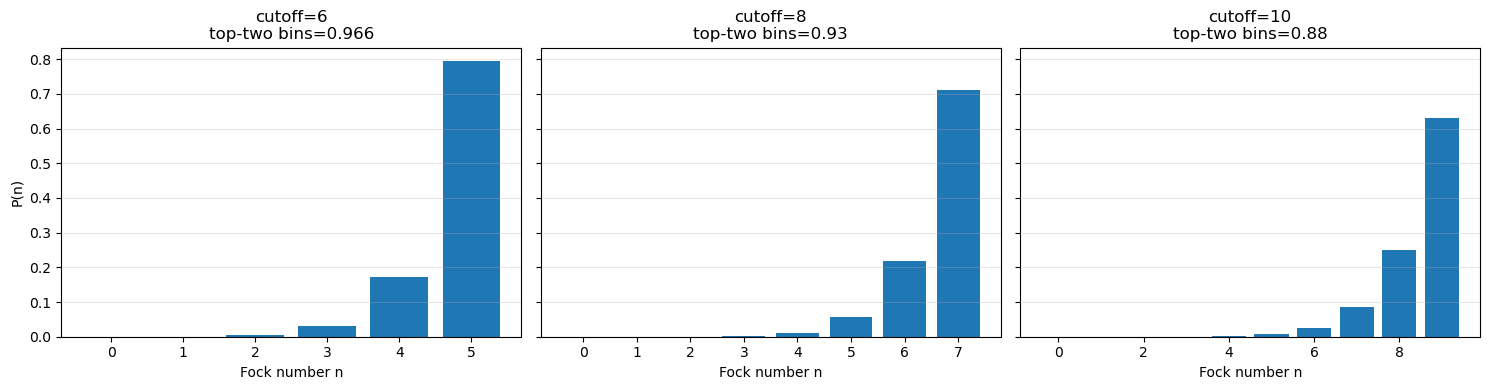

cutoff= 6: trace=1.000000000, min_eigenvalue=4.331e-12, <n>=4.75478, top-two-bin population=0.96614
cutoff= 8: trace=1.000000000, min_eigenvalue=2.675e-12, <n>=6.62467, top-two-bin population=0.92957
cutoff=10: trace=1.000000000, min_eigenvalue=1.853e-12, <n>=8.46869, top-two-bin population=0.88049


In [31]:
FOCK_CUTOFFS = (6, 8, 10)
ML_ITERATIONS = 200

rho_by_cutoff = {}
for cutoff in FOCK_CUTOFFS:
    rho_by_cutoff[cutoff] = heterodyne_ml_density_matrix(
        signal_alpha,
        cutoff=cutoff,
        iterations=ML_ITERATIONS,
        dilution=0.5,
    )

fig, axes = plt.subplots(1, len(FOCK_CUTOFFS), figsize=(15, 4), sharey=True)
for axis_plot, cutoff in zip(axes, FOCK_CUTOFFS):
    population = np.maximum(
        np.real(np.diag(rho_by_cutoff[cutoff])),
        0.0,
    )
    tail_population = np.sum(population[-2:])
    axis_plot.bar(np.arange(cutoff), population)
    axis_plot.set_title(
        f"cutoff={cutoff}\ntop-two bins={tail_population:.3g}"
    )
    axis_plot.set_xlabel("Fock number n")
    axis_plot.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("P(n)")
plt.tight_layout()
plt.show()

for cutoff in FOCK_CUTOFFS:
    rho_test = rho_by_cutoff[cutoff]
    population = np.maximum(np.real(np.diag(rho_test)), 0.0)
    photon_number = np.sum(np.arange(cutoff) * population)
    tail_population = np.sum(population[-2:])
    print(
        f"cutoff={cutoff:2d}: "
        f"trace={np.trace(rho_test).real:.9f}, "
        f"min_eigenvalue={np.min(np.linalg.eigvalsh(rho_test)):.3e}, "
        f"<n>={photon_number:.5f}, "
        f"top-two-bin population={tail_population:.5f}"
    )

FOCK_CUTOFF = max(FOCK_CUTOFFS)
rho_ml = rho_by_cutoff[FOCK_CUTOFF]
photon_population = np.maximum(np.real(np.diag(rho_ml)), 0.0)
cutoff_tail = np.sum(photon_population[-2:])

if cutoff_tail > 0.01:
    print(
        "WARNING: More than 1% population is in the top two Fock bins. "
        "Increase the cutoff before interpreting photon number or Wigner data."
    )

### 4.10 Wigner function and interpretation checks

Only evaluate the Wigner function after checking cutoff convergence. A
negative value is not sufficient evidence of a single photon when:

- the Fock cutoff is saturated;
- amplifier noise is modeled as ideal vacuum;
- total efficiency is unknown;
- the temporal mode was optimized on the same noisy data;
- statistical uncertainty has not been estimated.

For the weak coherent demonstration, the expected state is a coherent state
with amplitude `mean(signal_alpha)`, and its Wigner function should be
non-negative. Strong negative values therefore indicate an analysis,
calibration, or cutoff problem rather than nonclassical radiation.

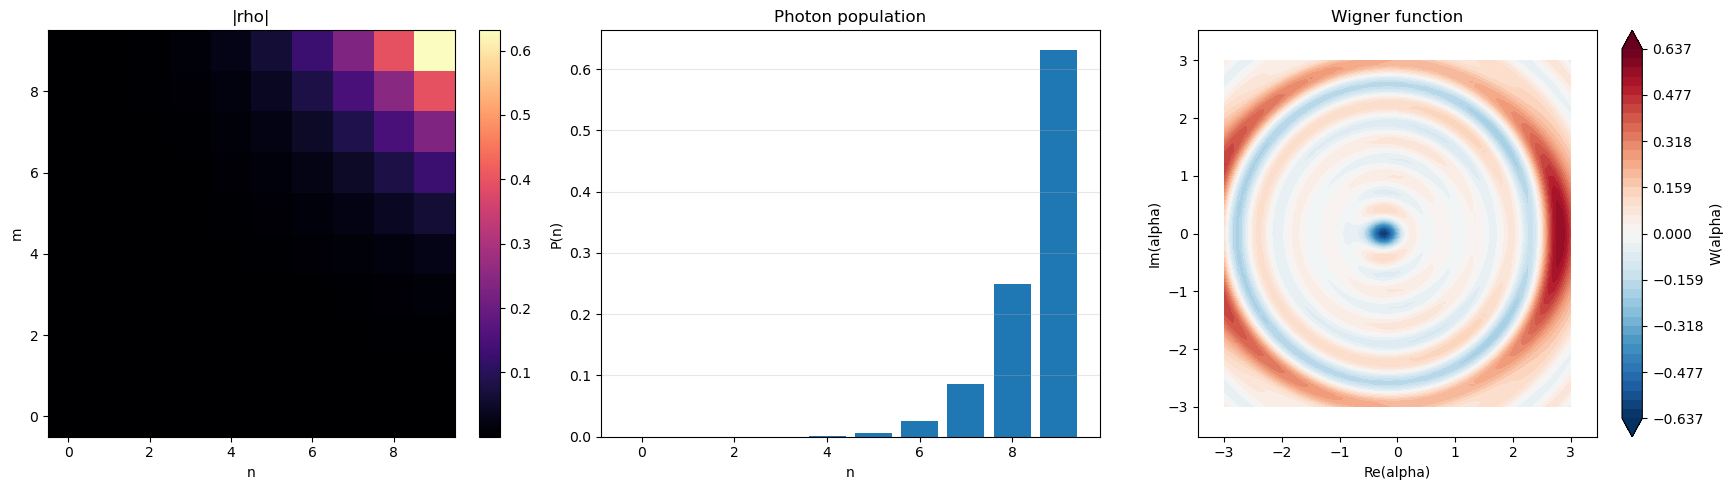

Trace rho: (0.9999999999999999+0j)
Minimum eigenvalue: 1.8534900342333794e-12
Top-two Fock-bin population: 0.8804880559603921
Wigner minimum: -0.6312616569998822
Fidelity to coherent state at mean alpha: 0.9999220353230632
Do not interpret this Wigner function: cutoff is not converged.


In [32]:
alpha_mean = np.mean(signal_alpha)
rho_coherent = coherent_density_matrix(
    alpha_mean,
    cutoff=FOCK_CUTOFF,
)
fidelity_to_coherent = float(
    np.real(np.trace(rho_ml @ rho_coherent))
)

WIGNER_LIMIT = 3.0
WIGNER_POINTS = 81
wigner_axis = np.linspace(
    -WIGNER_LIMIT,
    WIGNER_LIMIT,
    WIGNER_POINTS,
)
wigner = wigner_function(
    rho_ml,
    wigner_axis,
    wigner_axis,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
image = axes[0].imshow(np.abs(rho_ml), origin="lower", cmap="magma")
axes[0].set_title("|rho|")
axes[0].set_xlabel("n")
axes[0].set_ylabel("m")
plt.colorbar(image, ax=axes[0], fraction=0.046)

axes[1].bar(np.arange(FOCK_CUTOFF), photon_population)
axes[1].set_title("Photon population")
axes[1].set_xlabel("n")
axes[1].set_ylabel("P(n)")
axes[1].grid(True, axis="y", alpha=0.3)

levels = np.linspace(-2 / np.pi, 2 / np.pi, 41)
contour = axes[2].contourf(
    wigner_axis,
    wigner_axis,
    wigner,
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)
axes[2].set_title("Wigner function")
axes[2].set_xlabel("Re(alpha)")
axes[2].set_ylabel("Im(alpha)")
axes[2].axis("equal")
plt.colorbar(contour, ax=axes[2], label="W(alpha)")
plt.tight_layout()
plt.show()

print("Trace rho:", np.trace(rho_ml))
print("Minimum eigenvalue:", np.min(np.linalg.eigvalsh(rho_ml)))
print("Top-two Fock-bin population:", cutoff_tail)
print("Wigner minimum:", np.min(wigner))
print("Fidelity to coherent state at mean alpha:", fidelity_to_coherent)

if cutoff_tail > 0.01:
    print("Do not interpret this Wigner function: cutoff is not converged.")
elif np.min(wigner) < -0.05 and TOMO_STATE_GAIN != 0:
    print(
        "WARNING: The prepared demonstration state is coherent, so strong "
        "Wigner negativity indicates a calibration/POVM/statistics problem."
    )

### 4.11 Checklist before real Fock-state tomography

1. Run resonator spectroscopy and confirm the cavity/LO frequency.
2. Use `gain=1` only for signal-path and complex temporal-mode calibration.
3. Confirm the expected 520 ns pulse end for 500 ns padding and 580 ns delay.
4. Confirm CHB and check that the raw ADC signal is not clipping.
5. Freeze the independently measured temporal mode.
6. Replace the weak coherent signal pulse with the photon-state preparation
   and cavity-release sequence.
7. Acquire reference and photon-state shots with identical timing.
8. Calibrate amplifier added noise and total measurement efficiency before
   interpreting photon populations or Wigner negativity.
9. Repeat the reconstruction at multiple Fock cutoffs.
10. Add bootstrap resampling before quoting uncertainties.

The saved `.npz` files contain complete shot-resolved traces, so temporal-mode
filters and reconstruction settings can be re-evaluated offline.

## Close hardware

In [ ]:
if "sgs" in globals():
    sgs.off()
    sgs.configure_lo_output(False)
    sgs.close()

if "experiment" in globals():
    experiment.close()